# PPI crosslink distance heatmaps (single-restraint Chai runs)

For each chosen protein pair **(Protein A, Protein B)** in the same order as Chai output folders (`pair_*_<ProtA>_<ProtB>_...`):

- **Rows**: one single-crosslink prediction directory; the structure used is `pred.model_idx_{k}.cif` where `k` is **`ipae_xl_window_mean_best_model_idx`** from your single-XL metrics CSV (zero-based, same as filenames). Rows are reordered so the first rows follow the same crosslink sequence as the first columns (diagonal = same restraint vs merged measurement); any extra single-XL runs come after, still sorted by `pair_*` index (then positions) within that tail.
- **Columns**: each **experimental** crosslink for that PPI from `naive_chai_multimer_MERGED_20260417.csv` (deduplicated with `merged_xl_key`). The first columns are those single-XL restraints in `pair_*` order so they align with the first rows; remaining crosslinks follow in the original residue-position sort.
- **Cell values**: Cα–Cα distance (Å) for that crosslink in that model, using the same chain-assignment logic as the processing scripts (sequence lengths from the proteome CSV). Each tile is labeled with that distance (one decimal); missing values show an em dash.

**CSV vs Chai folders:** `ipae_xl_window_mean_best_model_idx` must come from the ipae table computed on the **same** `pair_*` run as `CHAI_OUTPUT_ROOTS`. Here, `single_interXL_chai_outputs_20260329_20max_uncon_multi_A_OR_B_conf*` matches `singleXL_20max_unconfident_multimer_A_OR_B_mono_combined_ipae_window_20260417.csv`. If you use `singleXL_20max_unconfident_multimer_UNconfident_A_AND_B_mono_combined_ipae_window_20260417.csv`, set `CHAI_OUTPUT_ROOTS` to the outputs that produced that table.

Two output roots are searched (same layout); if the same restraint appears in both, the lower `pair_*` index wins, matching `build_pair_dir_lookup` in the XL processing scripts.

In [ ]:
from __future__ import annotations

import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as mpe
import matplotlib.colors as mcolors
from Bio.PDB import MMCIFParser
import seaborn as sns
from scipy.cluster import hierarchy
from scipy.cluster.hierarchy import dendrogram
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle
import sys

sys.path.insert(0, str(Path(__file__).resolve().parents[1]))
from config import REPO_ROOT, PROTEOME_CSV, CHAI_MULTIMER_DIR, PROCESSED_DATA_DIR

BASE_DIR = REPO_ROOT

#paths should match your outputs from the xlrestraint_multimer_inference.py script
CHAI_OUTPUT_ROOTS = (
    CHAI_MULTIMER_DIR
    / "single_interXL_20A_distance/single_interXL_chai_outputs_20max_uncon_multi_A_OR_B_conf",
    CHAI_MULTIMER_DIR
    / "single_interXL_20A_distance/single_interXL_chai_outputs_20max_uncon_multi_A_OR_B_conf_node2",
    CHAI_MULTIMER_DIR
    / "single_interXL_20A_distance/single_interXL_chai_outputs_20max_unconf_multi_neither_conf_mono"
)

# Must match CHAI_OUTPUT_ROOTS (same batch of pair_* folders).
IPAE_CSV = (
    PROCESSED_DATA_DIR
    / "05_xlrestraint_multimer_unconfident_A_OR_B.csv",
    PROCESSED_DATA_DIR
    / "06_xlrestraint_multimer_unconfident_A_AND_B.csv"
)

MERGED_CSV = PROCESSED_DATA_DIR / "03_naive_multimer_inter_xl_calculations.csv"
PROTEOME_CSV = PROTEOME_CSV

NAIVE_CHAI_ROOTS = CHAI_MULTIMER_DIR / "naive_chai_ppis_noXLs"

#adjust this to the pair of interest
PPI_LIST = [("TGRH88_043730", "TGRH88_072250"),#A or B unconfident 
            ("TGRH88_010940", "TGRH88_069520")] #A and B unconfident




DIR_RE = re.compile(r"^pair_(\d+)_(TGRH88_\d+)_(TGRH88_\d+)_(.+)$")
NAIVE_DIR_RE = re.compile(r"^pair_(\d+)_(TGRH88_\d+)_(TGRH88_\d+)")

# colors = [
#     (0.0, greens(0.9)),   # dark green
#     (0.42, greens(0.35)),   # light green near threshold
#     (0.5, (1.0, 1.0, 1.0, 1.0)),
#     (0.58, reds(0.35)),     # light red near threshold
#     (1.0, reds(0.9))      # dark red
# ]

#update for manuscript colors
LOW = "#B68416"
HIGH = "#4E4EAE"
MID = "#F8F6F2" # optional light neutral; or use white "#FFFFFF"

# LOW = "#006400"
# HIGH = "#850101"
# MID = "#F8F6F2" # optional light neutral; or use white "#FFFFFF"

cmap_custom = LinearSegmentedColormap.from_list("gold_purple_split", [LOW, MID, HIGH])
norm = mcolors.TwoSlopeNorm(vmin=0, vcenter=35, vmax=70)

In [15]:
class MidpointNormalize(mcolors.Normalize):
    def __init__(self, vmin=None, vmax=None, midpoint=None):
        self.midpoint = midpoint
        super().__init__(vmin, vmax)

    def __call__(self, value, clip=None):
        # normalize to 0–1
        result = np.ma.masked_array((value - self.vmin) / (self.vmax - self.vmin))

        # piecewise scaling
        lower = value <= self.midpoint
        upper = value > self.midpoint

        result = np.ma.array(result)
        result[lower] = 0.5 * (value[lower] - self.vmin) / (self.midpoint - self.vmin)
        result[upper] = 0.5 + 0.5 * (value[upper] - self.midpoint) / (self.vmax - self.midpoint)

        return result


def make_xl_id(residue_a, pos_a, residue_b, pos_b) -> str:
    pos_a = int(float(pos_a))
    pos_b = int(float(pos_b))
    ra = str(residue_a).strip() if pd.notna(residue_a) and str(residue_a).strip() else "K"
    rb = str(residue_b).strip() if pd.notna(residue_b) and str(residue_b).strip() else "K"
    return f"{ra}{pos_a}_{rb}{pos_b}"


def build_pair_dir_lookup(chai_output_roots: tuple[Path, ...]) -> dict[tuple[str, str, str], tuple[Path, str]]:
    """
    (protein_a, protein_b, xl_id) -> (pair_directory, status)
    xl_id matches folder suffix after second protein id (e.g. K436_K829).
    """
    candidates: dict[tuple[str, str, str], tuple[int, Path]] = {}
    for root in chai_output_roots:
        if not root.is_dir():
            continue
        for d in root.iterdir():
            if not d.is_dir():
                continue
            m = DIR_RE.match(d.name)
            if not m:
                continue
            pair_idx = int(m.group(1))
            prot_a, prot_b = m.group(2), m.group(3)
            xl_id = m.group(4)
            key = (prot_a, prot_b, xl_id)
            if key not in candidates or pair_idx < candidates[key][0]:
                candidates[key] = (pair_idx, d)

    lookup = {}
    for key, (_, d) in candidates.items():
        n_cif = len(list(d.glob("pred.model_idx_*.cif")))
        n_npz = len(list(d.glob("scores.model_idx_*.npz")))
        st = "valid" if n_cif == 5 and n_npz == 5 else "incomplete_files"
        lookup[key] = (d, st)
    return lookup


def order_models_by_idx(path: Path) -> int | None:
    m = re.search(r"model_idx_(\d+)", path.name)
    return int(m.group(1)) if m else None


def extract_coords_from_cif(cif_path: Path) -> tuple[dict[tuple[str, int], np.ndarray], dict]:
    parser = MMCIFParser(QUIET=True)
    structure = parser.get_structure("model", str(cif_path))
    coords_dict: dict[tuple[str, int], np.ndarray] = {}
    chain_residues: dict = {}
    for model in structure:
        for chain in model:
            chain_residues[chain.id] = []
            for residue in chain:
                if "CA" in residue:
                    res_num = residue.id[1]
                    coords_dict[(chain.id, res_num)] = residue["CA"].coord
                    chain_residues[chain.id].append((res_num, residue.resname))
        break
    return coords_dict, chain_residues


def get_chain_assignment(
    coords_dict: dict[tuple[str, int], np.ndarray], len_protein1: int, len_protein2: int
) -> tuple[bool, str, str]:
    len_chain_A = len([k for k in coords_dict if k[0] == "A"])
    len_chain_B = len([k for k in coords_dict if k[0] == "B"])
    match_A_to_protA = abs(len_chain_A - len_protein1) <= 1
    match_A_to_protB = abs(len_chain_A - len_protein2) <= 1
    match_B_to_protA = abs(len_chain_B - len_protein1) <= 1
    match_B_to_protB = abs(len_chain_B - len_protein2) <= 1
    if match_A_to_protA and match_B_to_protB and not (match_A_to_protB and match_B_to_protA):
        return False, "A", "B"
    if match_A_to_protB and match_B_to_protA and not (match_A_to_protA and match_B_to_protB):
        return True, "B", "A"
    raise ValueError(
        f"Ambiguous chain assignment: chainA={len_chain_A}, chainB={len_chain_B}, "
        f"protA={len_protein1}, protB={len_protein2}"
    )


def calculate_distance(coords_dict, chain1, res1, chain2, res2):
    coord1 = coords_dict.get((chain1, res1))
    coord2 = coords_dict.get((chain2, res2))
    if coord1 is None or coord2 is None:
        return None
    return float(np.sqrt(np.sum((coord1 - coord2) ** 2)))


def load_seq_lengths(proteome_csv: Path, id_col: str = "Gene_ID", seq_col: str = "Protein_Sequence") -> dict[str, int]:
    df = pd.read_csv(proteome_csv)
    return {str(r[id_col]): len(str(r[seq_col])) for _, r in df.iterrows()}


def get_pair_dir_for_row(lookup, row) -> tuple[Path | None, str, str | None]:
    protein_a = row["Protein A"]
    protein_b = row["Protein B"]
    pos_a, pos_b = row.get("Crosslink Position A"), row.get("Crosslink Position B")
    res_a, res_b = row.get("Crosslinked Residue A"), row.get("Crosslinked Residue B")
    if pd.isna(pos_a) or pd.isna(pos_b):
        return None, "missing_crosslink_positions", None
    xl_id = make_xl_id(res_a, pos_a, res_b, pos_b)
    xl_swapped = make_xl_id(res_b, pos_b, res_a, pos_a)
    hit = lookup.get((protein_a, protein_b, xl_id))
    if hit is None:
        hit = lookup.get((protein_b, protein_a, xl_swapped))
    if hit is None:
        return None, "no_directory_found", None
    return hit[0], hit[1], xl_id


def xl_measurement_label(row) -> str:
    ra = row["Crosslinked Residue A"] if pd.notna(row["Crosslinked Residue A"]) else "?"
    rb = row["Crosslinked Residue B"] if pd.notna(row["Crosslinked Residue B"]) else "?"
    pa = int(float(row["Crosslink Position A"]))
    pb = int(float(row["Crosslink Position B"]))
    return f"{row['Protein A']}|{ra}{pa} — {row['Protein B']}|{rb}{pb}"


def restraint_row_label(row) -> str:
    return make_xl_id(
        row["Crosslinked Residue A"],
        row["Crosslink Position A"],
        row["Crosslinked Residue B"],
        row["Crosslink Position B"],
    )


def merged_xl_key(row) -> tuple:
    """Canonical key for deduping experimental XLs regardless of A/B column swap."""
    pa, pb = row["Protein A"], row["Protein B"]
    a = (pa, int(float(row["Crosslink Position A"])), str(row["Crosslinked Residue A"]).strip())
    b = (pb, int(float(row["Crosslink Position B"])), str(row["Crosslinked Residue B"]).strip())
    return tuple(sorted([a, b]))


def distance_merged_row_to_cif(
    coords_dict: dict,
    chain_a_id: str,
    chain_b_id: str,
    restraint_pa: str,
    restraint_pb: str,
    exp_row: pd.Series,
) -> float | None:
    """
    exp_row: one row from merged table (defines which protein each position belongs to).
    chain_a_id / chain_b_id are CIF chains that contain restraint_pa / restraint_pb respectively
    (from get_chain_assignment with lengths for the restraint row's Protein A / Protein B).
    """
    epa, epb = exp_row["Protein A"], exp_row["Protein B"]
    pos_ea = int(float(exp_row["Crosslink Position A"]))
    pos_eb = int(float(exp_row["Crosslink Position B"]))

    def chain_for_protein(target_prot: str) -> str | None:
        if target_prot == restraint_pa:
            return chain_a_id
        if target_prot == restraint_pb:
            return chain_b_id
        return None

    c1 = chain_for_protein(epa)
    c2 = chain_for_protein(epb)
    if c1 is None or c2 is None:
        return None
    return calculate_distance(coords_dict, c1, pos_ea, c2, pos_eb)


pair_lookup = build_pair_dir_lookup(CHAI_OUTPUT_ROOTS)
seq_lens = load_seq_lengths(PROTEOME_CSV)
print(f"pair directories indexed: {len(pair_lookup)}")

pair directories indexed: 4693


In [16]:
## Naive prediction addition
naive_lookup_df = NAIVE_DF.groupby(["Protein A", "Protein B"]).first().reset_index()

naive_dir_lookup = {}
for root in NAIVE_CHAI_ROOTS:
    for d in Path(root).iterdir():
        m = NAIVE_DIR_RE.match(d.name)
        if m:
            naive_dir_lookup[(m.group(2), m.group(3))] = d


IPAE CSV / directory pair overlap: 1093 (of 1093 ipae pairs)
No ipae rows for TGRH88_043730 / TGRH88_072250
n_matched: 6


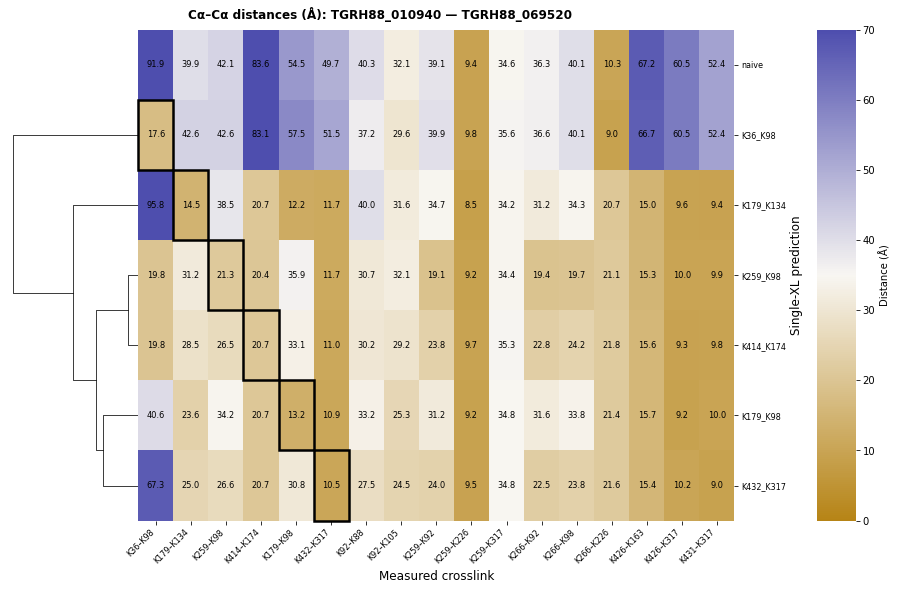

,restraint_xl,experimental_xl,distance_A,cif,best_model_idx,status,chains_swapped_vs_restraint_csv
0,naive,TGRH88_010940|K259 — TGRH88_069520|K98,42.116169,/home/ubuntu/chai-lab/updated_analyses_SL/chai...,1,naive,NaN
1,naive,TGRH88_010940|K179 — TGRH88_069520|K134,39.933716,/home/ubuntu/chai-lab/updated_analyses_SL/chai...,1,naive,NaN
2,naive,TGRH88_010940|K179 — TGRH88_069520|K98,54.521301,/home/ubuntu/chai-lab/updated_analyses_SL/chai...,1,naive,NaN
3,naive,TGRH88_010940|K36 — TGRH88_069520|K98,91.949745,/home/ubuntu/chai-lab/updated_analyses_SL/chai...,1,naive,NaN
4,naive,TGRH88_010940|K432 — TGRH88_069520|K317,49.693859,/home/ubuntu/chai-lab/updated_analyses_SL/chai...,1,naive,NaN
5,naive,TGRH88_010940|K414 — TGRH88_069520|K174,83.646378,/home/ubuntu/chai-lab/updated_analyses_SL/chai...,1,naive,NaN
6,naive,TGRH88_010940|K92 — TGRH88_069520|K88,40.273205,/home/ubuntu/chai-lab/updated_analyses_SL/chai...,1,naive,NaN
7,naive,TGRH88_010940|K92 — TGRH88_069520|K105,32.066769,/home/ubuntu/chai-lab/updated_analyses_SL/chai...,1,naive,NaN
8,naive,TGRH88_010940|K259 — TGRH88_069520|K92,39.052391,/home/ubuntu/chai-lab/updated_analyses_SL/chai...,1,naive,NaN
9,naive,TGRH88_010940|K259 — TGRH88_069520|K226,9.396219,/home/ubuntu/chai-lab/updated_analyses_SL/chai...,1,naive,NaN


In [19]:
# >>> DENDROGRAM_FIX_V3 — row dendrogram uses scipy orientation=left (search this string) <<<
def best_cif_path(ppi_dir: Path, best_idx) -> Path | None:
    if pd.isna(best_idx):
        return None
    k = int(best_idx)
    p = ppi_dir / f"pred.model_idx_{k}.cif"
    return p if p.is_file() else None


def heatmap_for_ppi(
    user_prot_a: str,
    user_prot_b: str,
    ipae_df: pd.DataFrame,
    merged_df: pd.DataFrame,
    pair_lookup: dict,
    seq_lens: dict[str, int],
    vmax: float = 45.0,
) -> pd.DataFrame | None:
    """
    user_prot_a / user_prot_b: folder order (Protein A, Protein B).
    Returns long-form table of distances (or None if no ipae rows).
    """

    ## for single_XL prediction
    sub_ipae = ipae_df[
        (ipae_df["Protein A"] == user_prot_a) & (ipae_df["Protein B"] == user_prot_b)
    ].copy()
    if sub_ipae.empty:
        sub_ipae = ipae_df[
            (ipae_df["Protein A"] == user_prot_b) & (ipae_df["Protein B"] == user_prot_a)
        ].copy()
        if not sub_ipae.empty:
            user_prot_a, user_prot_b = user_prot_b, user_prot_a

    if sub_ipae.empty:
        print(f"No ipae rows for {user_prot_a} / {user_prot_b}")
        return None

    def _pair_idx_row(r):
        d, _, _ = get_pair_dir_for_row(pair_lookup, r)
        if d is None:
            return 10**9
        m = DIR_RE.match(d.name)
        return int(m.group(1)) if m else 10**9

    sub_ipae["_pair_idx"] = sub_ipae.apply(_pair_idx_row, axis=1)
    sub_ipae = sub_ipae.sort_values(["_pair_idx", "Crosslink Position A", "Crosslink Position B"], kind="mergesort")
    sub_ipae["_xlkey"] = sub_ipae.apply(merged_xl_key, axis=1)

    merged_pair = merged_df[
        ((merged_df["Protein A"] == user_prot_a) & (merged_df["Protein B"] == user_prot_b))
        | ((merged_df["Protein A"] == user_prot_b) & (merged_df["Protein B"] == user_prot_a))
    ].copy()
    merged_pair = merged_pair.dropna(
        subset=["Crosslink Position A", "Crosslink Position B"]
    )

    if merged_pair.empty:
        print(f"No merged crosslinks for {user_prot_a} / {user_prot_b}")
        return None

    merged_pair["_xlkey"] = merged_pair.apply(merged_xl_key, axis=1)
    exp_rows = merged_pair.groupby("_xlkey", as_index=False).first()
    _exp_pos_sort = [
        "Crosslink Position A",
        "Crosslink Position B",
        "Crosslinked Residue A",
        "Crosslinked Residue B",
    ]

    # Align axes: first rows/cols are the same crosslinks in pair_* order (diagonal = restraint vs measurement).
    exp_by_key = exp_rows.set_index("_xlkey")
    matched_keys: list = []
    seen_keys: set = set()
    for k in sub_ipae["_xlkey"]:
        if k in exp_by_key.index and k not in seen_keys:
            seen_keys.add(k)
            matched_keys.append(k)

    matched_exp = exp_by_key.reindex(matched_keys).reset_index()
    n_matched = len(matched_keys)
    print(f"n_matched: {n_matched}")
    unmatched_exp = (
        exp_rows[~exp_rows["_xlkey"].isin(seen_keys)]
        .sort_values(_exp_pos_sort, kind="mergesort")
    )
    exp_rows = pd.concat([matched_exp, unmatched_exp], ignore_index=True)

    has_exp = sub_ipae["_xlkey"].isin(seen_keys)
    sub_ipae = pd.concat([sub_ipae[has_exp], sub_ipae[~has_exp]], ignore_index=True)

    def short_xl_label(r):
        return f"{r['Crosslinked Residue A']}{int(float(r['Crosslink Position A']))}–{r['Crosslinked Residue B']}{int(float(r['Crosslink Position B']))}"

    col_labels = [short_xl_label(r) for _, r in exp_rows.iterrows()]

    rows_out = []
    mat = []
    row_labels = []
    row_keys: list = []
    naive_row_added = False

    ## for naive prediction 
    naive_idx_col = "ipae_interface_mean_best_model_idx"

    # Find the matching row in naive CSV
    naive_row_df = naive_lookup_df[
        ((naive_lookup_df["Protein A"] == user_prot_a) & (naive_lookup_df["Protein B"] == user_prot_b))
        | ((naive_lookup_df["Protein A"] == user_prot_b) & (naive_lookup_df["Protein B"] == user_prot_a))
    ]

    naive_ppi_dir = naive_dir_lookup.get((user_prot_a, user_prot_b)) or \
                    naive_dir_lookup.get((user_prot_b, user_prot_a))

    if not naive_row_df.empty and naive_ppi_dir is not None:
        naive_best_idx = naive_row_df.iloc[0][naive_idx_col]
        naive_cif = best_cif_path(naive_ppi_dir, naive_best_idx)

        if naive_cif is not None:
            len_a = seq_lens.get(str(user_prot_a))
            len_b = seq_lens.get(str(user_prot_b))
            coords, _ = extract_coords_from_cif(naive_cif)
            swapped, chain_a_id, chain_b_id = get_chain_assignment(coords, len_a, len_b)

            naive_row_vals = []
            for _, er in exp_rows.iterrows():
                d = distance_merged_row_to_cif(
                    coords, chain_a_id, chain_b_id, user_prot_a, user_prot_b, er
                )
                naive_row_vals.append(d)
                rows_out.append({
                    "restraint_xl": "naive",
                    "experimental_xl": xl_measurement_label(er),
                    "distance_A": d,
                    "cif": str(naive_cif),
                    "best_model_idx": int(naive_best_idx) if pd.notna(naive_best_idx) else None,
                    "status": "naive",
                })
            mat.insert(0, naive_row_vals)
            row_labels.insert(0, "naive")
            row_keys.insert(0, None)
            naive_row_added = True

    ## single-XL loop
    for _, ir in sub_ipae.iterrows():
        ppi_dir, st, _xlid = get_pair_dir_for_row(pair_lookup, ir)
        label = restraint_row_label(ir)
        row_labels.append(label)
        row_keys.append(ir["_xlkey"])

        if ppi_dir is None or st != "valid":
            mat.append([np.nan] * len(exp_rows))
            for _, er in exp_rows.iterrows():
                rows_out.append(
                    {
                        "restraint_xl": label,
                        "experimental_xl": xl_measurement_label(er),
                        "distance_A": np.nan,
                        "ppi_dir": str(ppi_dir) if ppi_dir else None,
                        "status": st,
                    }
                )
            continue

        idx_col = "ipae_xl_window_mean_best_model_idx"
        if idx_col not in ir.index:
            raise KeyError(f"Missing column {idx_col!r} on ipae table")
        cif_path = best_cif_path(ppi_dir, ir[idx_col])
        if cif_path is None:
            mat.append([np.nan] * len(exp_rows))
            for _, er in exp_rows.iterrows():
                rows_out.append(
                    {
                        "restraint_xl": label,
                        "experimental_xl": xl_measurement_label(er),
                        "distance_A": np.nan,
                        "ppi_dir": str(ppi_dir),
                        "status": "missing_best_cif",
                    }
                )
            continue

        rpa, rpb = ir["Protein A"], ir["Protein B"]
        len_a = seq_lens.get(str(rpa))
        len_b = seq_lens.get(str(rpb))
        if len_a is None or len_b is None:
            print(f"Missing sequence length for {rpa} or {rpb}")
            mat.append([np.nan] * len(exp_rows))
            for _, er in exp_rows.iterrows():
                rows_out.append(
                    {
                        "restraint_xl": label,
                        "experimental_xl": xl_measurement_label(er),
                        "distance_A": np.nan,
                        "ppi_dir": str(ppi_dir),
                        "status": "missing_proteome_length",
                    }
                )
            continue

        coords, _ = extract_coords_from_cif(cif_path)
        swapped, chain_a_id, chain_b_id = get_chain_assignment(coords, len_a, len_b)

        row_vals = []
        for _, er in exp_rows.iterrows():
            d = distance_merged_row_to_cif(coords, chain_a_id, chain_b_id, rpa, rpb, er)
            row_vals.append(d)
            rows_out.append(
                {
                    "restraint_xl": label,
                    "experimental_xl": xl_measurement_label(er),
                    "distance_A": d,
                    "cif": str(cif_path),
                    "best_model_idx": int(ir[idx_col]) if pd.notna(ir[idx_col]) else None,
                    "chains_swapped_vs_restraint_csv": swapped,
                    "status": "ok",
                }
            )
        mat.append(row_vals)
    M = np.array(mat, dtype=float)
    n_rows = len(row_labels)
    df_hm = pd.DataFrame(M, index=pd.RangeIndex(n_rows), columns=col_labels)
    miss = ~np.isfinite(M)
    fill = float(np.nanmedian(M)) if np.any(np.isfinite(M)) else 0.0
    df_cluster = df_hm.where(~miss, other=fill)

    ny, nx = M.shape
    fs = max(5.0, min(9.0, 140.0 / max(nx, ny, 1)))
    ann = np.empty(M.shape, dtype=object)
    for iy in range(ny):
        for ix in range(nx):
            v = M[iy, ix]
            ann[iy, ix] = f"{v:.1f}" if np.isfinite(v) else "—"

    w = max(10.0, len(col_labels) * 0.45 + 3.0)
    h = max(8.0, len(row_labels) * 0.45 + 3.0)

    # Row-only hierarchical clustering; columns follow the same crosslink order (shared xlkey ordering).
    col_keys = exp_rows["_xlkey"].tolist()
    has_naive = n_rows > 0 and row_keys[0] is None
    cluster_row_idx = [i for i in range(n_rows) if row_keys[i] is not None]
    row_linkage = None
    if len(cluster_row_idx) >= 2:
        row_linkage = hierarchy.linkage(
            df_cluster.iloc[cluster_row_idx].values,
            method="average",
            metric="euclidean",
        )
        ord_sub = hierarchy.leaves_list(row_linkage).tolist()
        row_order = ([0] if has_naive else []) + [cluster_row_idx[i] for i in ord_sub]
    else:
        row_order = list(range(n_rows))

    col_order: list[int] = []
    used_cols: set[int] = set()
    for ri in row_order:
        k = row_keys[ri]
        if k is None:
            continue
        for j, ck in enumerate(col_keys):
            if ck == k and j not in used_cols:
                col_order.append(j)
                used_cols.add(j)
                break
    for j in range(nx):
        if j not in used_cols:
            col_order.append(j)

    M_plot = M[np.ix_(row_order, col_order)]
    miss_plot = miss[np.ix_(row_order, col_order)]
    ann_plot = ann[np.ix_(row_order, col_order)]
    row_labels_p = [row_labels[i] for i in row_order]
    col_labels_p = [col_labels[j] for j in col_order]
    row_keys_p = [row_keys[i] for i in row_order]
    col_keys_p = [col_keys[j] for j in col_order]
    df_cluster_plot = pd.DataFrame(
        df_cluster.values[np.ix_(row_order, col_order)],
        index=pd.RangeIndex(len(row_order)),
        
        columns=col_labels_p,
    )

    def _draw_row_dendrogram(ax, Z, leaf_y_centers, heatmap_ylim, linewidth=0.75):
        """Left-facing row dendrogram (root left, leaves right toward heatmap). dendrogram_v3"""
        n = len(leaf_y_centers)
        if n == 0:
            return
        ax.cla()

        def map_y(y):
            k = (y - 5.0) / 10.0
            i0 = int(np.floor(np.clip(k, 0, max(n - 1, 0))))
            i1 = min(i0 + 1, n - 1)
            frac = float(np.clip(k - i0, 0, 1))
            return (1.0 - frac) * leaf_y_centers[i0] + frac * leaf_y_centers[i1]

        # scipy ax= draws LineCollection; get_lines() is empty. Build segments manually.
        dd = dendrogram(Z, no_plot=True, orientation="left")
        for xs, ys in zip(dd["dcoord"], dd["icoord"]):
            ax.plot(
                xs,
                [map_y(y) for y in ys],
                color="k",
                lw=linewidth,
                solid_capstyle="round",
                clip_on=False,
            )

        xmax = max((max(xs) for xs in dd["dcoord"]), default=0.0)
        ax.set_ylim(heatmap_ylim[0], heatmap_ylim[1])
        ax.set_xlim(max(xmax * 1.05, 0.5), 0.0)
        ax.set_aspect("auto")
        ax.axis("off")

    def _place_colorbar_right(g, pad=0.018):
        if getattr(g, "cax", None) is None:
            return

        g.fig.canvas.draw()  # ensure all tick labels are rendered before measuring

        # Get the actual rendered right edge of the heatmap (including tick labels)
        renderer = g.fig.canvas.get_renderer()
        hm_bbox = g.ax_heatmap.get_tightbbox(renderer)
        fig_width = g.fig.get_size_inches()[0] * g.fig.dpi
        right_fig_frac = hm_bbox.x1 / fig_width  # rightmost edge in figure fraction

        pos_h = g.ax_heatmap.get_position()
        cw = max(0.018, g.cax.get_position().width)
        g.cax.set_position([right_fig_frac + pad, pos_h.y0, cw, pos_h.height])

    g = sns.clustermap(
        df_cluster_plot,
        cmap=cmap_custom,
        norm=norm,
        mask=miss_plot,
        # Rows/cols already reordered (scipy linkage + shared _xlkey col order); draw tree manually.
        row_cluster=False,
        col_cluster=False,
        figsize=(w, h),
        yticklabels=row_labels_p,
        annot=ann_plot,
        fmt="",
        annot_kws={"size": fs, "color": "black"},
        linewidths=0.0,
        cbar_kws={"label": "Distance (Å)"},
        dendrogram_ratio=(0.18, 0.0),
        tree_kws={"linewidths": 0.75},
    )

    if row_linkage is not None:
        plot_idx = [p for p in range(len(row_order)) if row_keys_p[p] is not None]
        Z_display = hierarchy.linkage(
            df_cluster_plot.iloc[plot_idx].values,
            method="average",
            metric="euclidean",
        )
        y_centers = [p + 0.5 for p in plot_idx]
        g.ax_row_dendrogram.cla()
        _draw_row_dendrogram(
            g.ax_row_dendrogram,
            Z_display,
            y_centers,
            g.ax_heatmap.get_ylim(),
            linewidth=0.75,
        )
    g.ax_heatmap.set_xticklabels(
        g.ax_heatmap.get_xticklabels(), rotation=45, ha="right", fontsize=8
    )
    g.ax_heatmap.set_yticklabels(
        g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=8
    )
    g.ax_heatmap.set_ylabel(
        "Single-XL prediction", fontsize = 12)
    g.ax_heatmap.set_xlabel("Measured crosslink", fontsize = 12)
    g.fig.suptitle(
        f"Cα–Cα distances (Å): {user_prot_a} — {user_prot_b}",
        y=1.02,
        fontsize=12, fontweight = "bold",
    )

    # g.ax_heatmap.set_aspect("equal")

    g.fig.patch.set_facecolor("white")
    for ax in g.fig.axes:
        ax.set_facecolor("white")

    g.fig.canvas.draw()
    _place_colorbar_right(g)

    # Cell outlines: restraint row vs experimental column with the same _xlkey (after shared reordering).
    for p in range(len(row_order)):
        k = row_keys_p[p]
        if k is None:
            continue
        for q in range(len(col_order)):
            if col_keys_p[q] == k:
                rect = Rectangle(
                    (q, p),
                    1,
                    1,
                    linewidth=2.5,
                    edgecolor="black",
                    facecolor="none",
                    clip_on=False,
                    zorder=20,
                )
                g.ax_heatmap.add_patch(rect)
                break

    plt.show()

    return pd.DataFrame(rows_out)


ipae_df = pd.read_csv(IPAE_CSV)
merged_df = pd.read_csv(MERGED_CSV)

_ipae_pairs = set(zip(ipae_df["Protein A"], ipae_df["Protein B"]))
_dir_pairs = {k[:2] for k in pair_lookup}
_n = len(_ipae_pairs & _dir_pairs)
if _n == 0:
    print(
        "WARNING: no (Protein A, Protein B) pairs overlap between IPAE_CSV and CHAI_OUTPUT_ROOTS. "
        "Switch IPAE_CSV or CHAI_OUTPUT_ROOTS so they describe the same batch."
    )
else:
    print(f"IPAE CSV / directory pair overlap: {_n} (of {len(_ipae_pairs)} ipae pairs)")

try:
    from IPython.display import display as _display
except ImportError:
    _display = print

for pa, pb in PPI_LIST:
    tbl = heatmap_for_ppi(pa, pb, ipae_df, merged_df, pair_lookup, seq_lens)
    if tbl is not None:
        _display(tbl.head(12))
        